In [1]:
import pandas as pd
import numpy as np

In [2]:
X = pd.read_csv("../data/processed/secom_features_clean.csv")
time = pd.read_csv("../data/processed/secom_features_raw.csv").index

In [3]:
split_idx = int(len(X) * 0.7)

X_baseline = X.iloc[:split_idx]
X_current = X.iloc[split_idx:]

print("Baseline shape:", X_baseline.shape)
print("Current shape:", X_current.shape)


Baseline shape: (1096, 582)
Current shape: (471, 582)


In [4]:
baseline_mean = X_baseline.mean()
current_mean = X_current.mean()

drift_score = (current_mean - baseline_mean).abs()

drift_df = drift_score.sort_values(ascending=False).to_frame(name="drift_score")
drift_df.head(10)


,drift_score
sensor_28,0.838033
sensor_58,0.833069
sensor_440,0.818901
sensor_169,0.811104
sensor_393,0.797319
sensor_304,0.786590
sensor_571,0.776570
sensor_542,0.768111
sensor_132,0.754619
sensor_79,0.739490


In [5]:
threshold = drift_df["drift_score"].quantile(0.95)

drift_df["is_drifted"] = (drift_df["drift_score"] >= threshold).astype(int)

drift_df.head(10)


,drift_score,is_drifted
sensor_28,0.838033,1
sensor_58,0.833069,1
sensor_440,0.818901,1
sensor_169,0.811104,1
sensor_393,0.797319,1
sensor_304,0.786590,1
sensor_571,0.776570,1
sensor_542,0.768111,1
sensor_132,0.754619,1
sensor_79,0.739490,1


In [6]:
drift_df.to_csv("../data/processed/secom_drift_scores.csv")
print("Saved drift scores.")


Saved drift scores.


In [7]:
top_sensor = drift_df.index[0]
top_sensor


'sensor_28'

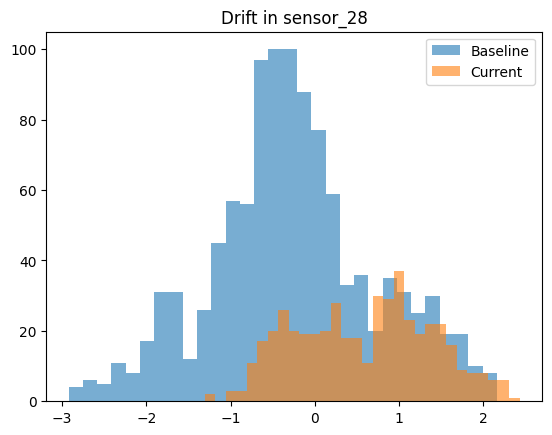

In [12]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(X_baseline[top_sensor], bins=30, alpha=0.6, label="Baseline")
plt.hist(X_current[top_sensor], bins=30, alpha=0.6, label="Current")
plt.title(f"Drift in {top_sensor}")
plt.legend()
plt.show()

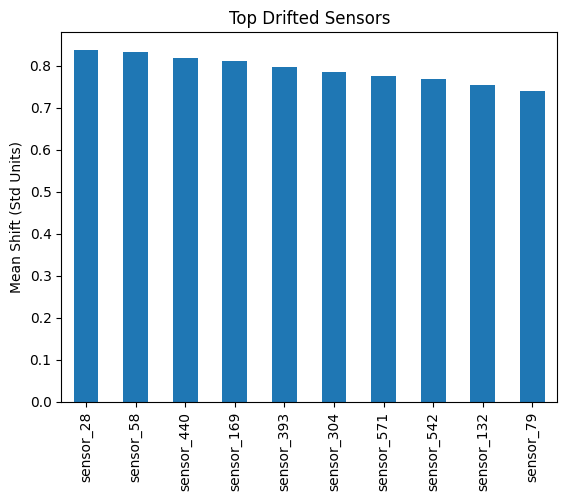

In [13]:
drift_df.head(10)["drift_score"].plot(kind="bar", title="Top Drifted Sensors")
plt.ylabel("Mean Shift (Std Units)")
plt.show()


In [14]:
scores = pd.read_csv("../data/processed/secom_anomaly_scores.csv")


In [16]:
anomalous_idx = scores[scores["is_anomaly"] == 1].index
normal_idx = scores[scores["is_anomaly"] == 0].index

len(anomalous_idx), len(normal_idx)

(47, 1520)

In [17]:
drifted_sensors = drift_df[drift_df["is_drifted"] == 1].index.tolist()
len(drifted_sensors)


30

In [18]:
mean_anomalous = X.loc[anomalous_idx, drifted_sensors].mean()
mean_normal = X.loc[normal_idx, drifted_sensors].mean()

impact_df = (mean_anomalous - mean_normal).abs().sort_values(ascending=False)
impact_df.head(10)


sensor_169    0.595043
sensor_440    0.549594
sensor_304    0.536470
sensor_66     0.512337
sensor_28     0.492958
sensor_79     0.451877
sensor_255    0.274849
sensor_527    0.271287
sensor_279    0.268966
sensor_545    0.265519
dtype: float64

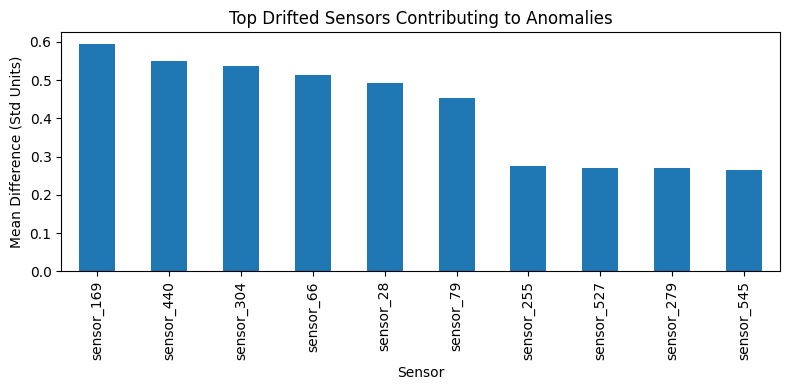

In [19]:
import matplotlib.pyplot as plt

top_impact = impact_df.head(10)

plt.figure(figsize=(8, 4))
top_impact.plot(kind="bar")
plt.title("Top Drifted Sensors Contributing to Anomalies")
plt.ylabel("Mean Difference (Std Units)")
plt.xlabel("Sensor")
plt.tight_layout()
plt.show()


C:\Users\Jose Iriarte\AppData\Local\Temp\ipykernel_30644\617450437.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=["Normal", "Anomalous"])


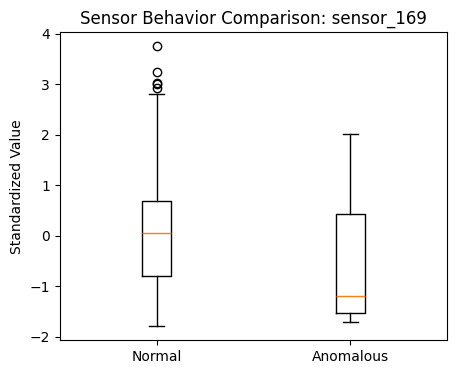

In [20]:
sensor = top_impact.index[0]

data_to_plot = [
    X.loc[normal_idx, sensor],
    X.loc[anomalous_idx, sensor]
]

plt.figure(figsize=(5, 4))
plt.boxplot(data_to_plot, labels=["Normal", "Anomalous"])
plt.title(f"Sensor Behavior Comparison: {sensor}")
plt.ylabel("Standardized Value")
plt.show()
